# Baseline Model

Build a simple baseline model for the Numerai dataset and evaluate its out-of-sample performance on the validation set.

## 1. Validation Data Overview

Inspect the validation dataset structure before loading feature data into memory.

In [11]:
from pathlib import Path
import pyarrow.parquet as pq

VALIDATION_PATH = Path("../data/validation.parquet")

validation_file = pq.ParquetFile(VALIDATION_PATH)

print("Rows:", validation_file.metadata.num_rows)
print("Columns:", validation_file.metadata.num_columns)
print("Row groups:", validation_file.metadata.num_row_groups)

Rows: 4128060
Columns: 3599
Row groups: 4


## 2. Validation Era Structure

Inspect the validation eras and data types to understand the out-of-sample evaluation period.

In [12]:
import pandas as pd

validation_meta = pd.read_parquet(
    VALIDATION_PATH,
    columns=["era", "data_type"],
)

print("Shape:", validation_meta.shape)
print("Number of eras:", validation_meta["era"].nunique())
print("First eras:", validation_meta["era"].unique()[:10])
print("Last eras:", validation_meta["era"].unique()[-10:])

print("\nData types:")
print(validation_meta["data_type"].value_counts())

Shape: (4128060, 2)
Number of eras: 660
First eras: <ArrowStringArray>
['0575', '0576', '0577', '0578', '0579', '0580', '0581', '0582', '0583',
 '0584']
Length: 10, dtype: str
Last eras: <ArrowStringArray>
['1225', '1226', '1227', '1228', '1229', '1230', '1231', '1232', '1233',
 '1234']
Length: 10, dtype: str

Data types:
data_type
validation    4036034
test            92026
Name: count, dtype: int64[pyarrow]


In [13]:
for data_type in validation_meta["data_type"].unique():
    subset = validation_meta[
        validation_meta["data_type"] == data_type
    ]

    print(f"Data type: {data_type}")
    print("Rows:", len(subset))
    print("Number of eras:", subset["era"].nunique())
    print("First era:", subset["era"].min())
    print("Last era:", subset["era"].max())
    print()

Data type: validation
Rows: 4036034
Number of eras: 647
First era: 0575
Last era: 1221

Data type: test
Rows: 92026
Number of eras: 13
First era: 1222
Last era: 1234



## 3. Feature and Target Selection

In [14]:
import json

FEATURES_PATH = Path("../data/features.json")

with open(FEATURES_PATH, "r",encoding="utf-8") as f:
    feature_metadata = json.load(f)

small_features = feature_metadata["feature_sets"]["small"]

print("Number of small features:", len(small_features))
print("First 5 features:", small_features[:5])

Number of small features: 42
First 5 features: ['feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba', 'feature_bridal_fingered_pensioner', 'feature_collectivist_flaxen_gueux', 'feature_concurring_fabled_adapter']


## 4. Load Baseline Data

Load only the era, target, data type, and 42 small features to keep memory usage manageable.

In [15]:
TRAIN_PATH = Path("../data/train.parquet")

train_cols = ["era", "target"] + small_features
validation_cols = ["era", "data_type", "target"] + small_features

train_baseline = pd.read_parquet(
    TRAIN_PATH,
    columns=train_cols,
)

validation_baseline = pd.read_parquet(
    VALIDATION_PATH,
    columns=validation_cols,
)

print("Train shape:", train_baseline.shape)
print("Validation shape:", validation_baseline.shape)

Train shape: (2746268, 44)
Validation shape: (4128060, 45)


In [16]:
validation_data = validation_baseline[
    validation_baseline["data_type"] == "validation"
].copy()

test_data = validation_baseline[
    validation_baseline["data_type"] == "test"
].copy()

print("Train:", train_baseline.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (2746268, 44)
Validation: (4036034, 45)
Test: (92026, 45)


## 5. Prepare Training and Validation Sets

Separate feature matrices and target vectors for model training and out-of-sample validation.

In [17]:
PURGE_ERAS = 16

validation_start_era = int(validation_data["era"].min())
train_end_era = validation_start_era - PURGE_ERAS - 1

train_purged = train_baseline[
    train_baseline["era"].astype(int) <= train_end_era
].copy()

print("Original train eras:", train_baseline["era"].nunique())
print("Purged train eras:", train_purged["era"].nunique())
print("Last training era:", train_purged["era"].max())
print("First validation era:", validation_data["era"].min())

Original train eras: 574
Purged train eras: 558
Last training era: 0558
First validation era: 0575


In [18]:
X_train = train_purged[small_features]
y_train = train_purged["target"]

X_valid = validation_data[small_features]
y_valid = validation_data["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (2657277, 42)
y_train: (2657277,)
X_valid: (4036034, 42)
y_valid: (4036034,)


## 6. Baseline Model Training

Train a simple LightGBM regression model using the 42 small features.

In [20]:
from lightgbm import LGBMRegressor

baseline_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1, #CPU
)

baseline_model.fit(
    X_train,
    y_train,
)
print("Baseline model training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 2657277, number of used features: 42
[LightGBM] [Info] Start training from score 0.499948
Baseline model training completed.


## 7. Validation Predictions

Generate out-of-sample predictions for the validation set using the trained baseline model.

In [21]:
valid_predictions = baseline_model.predict(X_valid)

print("Number of predictions:", len(valid_predictions))
print("First 10 predictions:", valid_predictions[:10])
print("Min prediction:", valid_predictions.min())
print("Max prediction:", valid_predictions.max())
print("Mean prediction:", valid_predictions.mean())

Number of predictions: 4036034
First 10 predictions: [0.49555588 0.50547802 0.49567997 0.51070949 0.51559322 0.49590401
 0.50574899 0.50538697 0.5022345  0.47111771]
Min prediction: 0.4282214484467095
Max prediction: 0.5902824496746346
Mean prediction: 0.499821924171437


## 8. Era-Level Evaluation

Evaluate the baseline model using cross-sectional correlation between predictions and targets within each validation era.

In [22]:
validation_results = validation_data[["era", "target"]].copy()
validation_results["prediction"] = valid_predictions

era_corr = validation_results.groupby("era").apply(
    lambda x: x["prediction"].corr(x["target"])
)

print(era_corr.describe())

count    647.000000
mean       0.018488
std        0.014958
min       -0.018352
25%        0.008046
50%        0.018574
75%        0.028468
max        0.066760
dtype: float64


## 9. Numerai CORR

Calculate the official Numerai CORR by ranking and Gaussianizing predictions, applying the power-1.5 transformation, and computing the correlation with the centered target within each era.

In [23]:
from scipy import stats
import numpy as np

In [24]:
def numerai_corr(preds, target):
    ranked_preds = (preds.rank(method="average") - 0.5) / preds.count()
    gauss_preds = stats.norm.ppf(ranked_preds)

    centered_target = target - target.mean()

    preds_p15 = np.sign(gauss_preds) * np.abs(gauss_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5

    return np.corrcoef(preds_p15, target_p15)[0, 1]

In [25]:
numerai_era_corr = validation_results.groupby("era").apply(
    lambda x: numerai_corr(x["prediction"], x["target"])
)

print(numerai_era_corr.describe())

count    647.000000
mean       0.017655
std        0.014758
min       -0.018555
25%        0.006975
50%        0.018351
75%        0.027422
max        0.061741
dtype: float64


## 10. Baseline Performance Summary

Summarize the baseline model using mean CORR, CORR Sharpe, positive-era rate, and cumulative CORR.

In [28]:
mean_corr = numerai_era_corr.mean()
std_corr = numerai_era_corr.std()

corr_sharpe = mean_corr / std_corr
positive_era_rate = (numerai_era_corr > 0).mean()

cumulative_corr = numerai_era_corr.cumsum()

print(f"Mean CORR: {mean_corr:.6f}")
print(f"CORR Std: {std_corr:.6f}")
print(f"CORR Sharpe-like Ratio: {corr_sharpe:.3f}")
print(f"Positive Era Rate: {positive_era_rate:.2%}")

Mean CORR: 0.017655
CORR Std: 0.014758
CORR Sharpe-like Ratio: 1.196
Positive Era Rate: 87.48%


<Axes: title={'center': 'Baseline Cumulative Numerai CORR'}, xlabel='Era', ylabel='Cumulative CORR'>

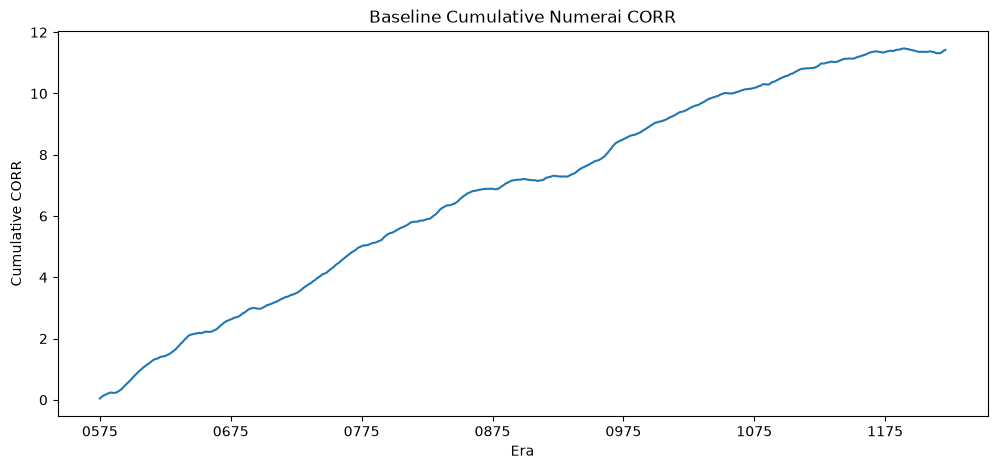

In [29]:
cumulative_corr.plot(
    figsize=(12, 5),
    title="Baseline Cumulative Numerai CORR",
    xlabel="Era",
    ylabel="Cumulative CORR",
)

<Axes: title={'center': '20-Era Rolling Mean Numerai CORR'}, xlabel='Era', ylabel='Rolling Mean CORR'>

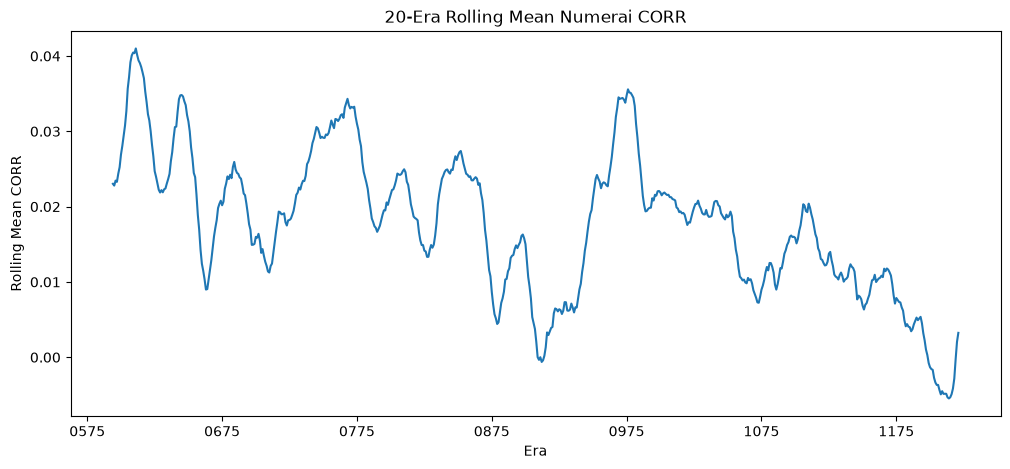

In [30]:
rolling_corr = numerai_era_corr.rolling(20).mean()

rolling_corr.plot(
    figsize=(12, 5),
    title="20-Era Rolling Mean Numerai CORR",
    xlabel="Era",
    ylabel="Rolling Mean CORR",
)

## 11. Baseline Summary

## 11. Baseline Summary

### Model Setup
- **Model:** LightGBM Regressor
- **Features:** Numerai `small` feature set (42 features)
- **Target:** Default Numerai target (`target_ender_60`)
- **Training eras:** `0001–0558`
- **Purged eras:** `0559–0574` (16 eras)
- **Validation eras:** `0575–1221`
- **Test eras:** `1222–1234` (reserved as an untouched final holdout)

### Validation Performance
- **Mean Numerai CORR:** 0.017655
- **CORR standard deviation:** 0.014758
- **CORR Sharpe-like ratio:** 1.196
- **Positive era rate:** 87.48%
- **Median CORR:** 0.018351
- **Minimum CORR:** -0.018555
- **Maximum CORR:** 0.061741

### Key Observations
- The simple 42-feature LightGBM baseline produces a positive and relatively stable out-of-sample signal.
- CORR is positive in approximately 87.5% of validation eras.
- Cumulative CORR increases steadily over most of the validation period, although performance varies across different periods.
- This model will serve as the baseline benchmark for future feature, model, target, and ensemble experiments.
- The test set remains untouched and will only be evaluated after selecting a stronger candidate model.